In [130]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

# import matplotlib.pyplot as plt
# plt.rc('font', family='NanumBarunGothic')
# plt.rcParams['axes.unicode_minus'] =False

In [131]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import lightgbm
from google.colab import drive

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False


# 드라이브 마운트
drive.mount('/content/drive')

# 경로 설정
PATH = "/content/drive/MyDrive/열수요예측/"
df_raw = pd.read_csv(PATH + "train_heat.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
# 이상치 처리
df = df_raw.copy()
df.columns = [col.split('.')[1] for col in df.columns]
for col in df.columns:
    df[col] = np.where(df[col] == -99, np.nan, df[col])
df['wd'] = np.where(df['wd'] < 0, np.nan, df['wd'])
df['si'] = np.where(df['si'] < 0, np.nan, df['si'])
df['rn_hr1'] = np.where(df['rn_hr1'] < 0, np.nan, df['rn_hr1'])

# 필요없는 컬럼 제거
#df.drop(['si', 'rn_hr1', 'ta_chi'], axis=1, inplace=True)

# 결측치 제거
df.dropna(inplace=True)

# 날짜 파싱 및 파생 변수 생성
df['tm'] = pd.to_datetime(df['tm'].astype(int), format='%Y%m%d%H')
df['month'] = df['tm'].dt.month
df['hour'] = df['tm'].dt.hour

# 요일 및 주말 여부
df['weekday'] = df['tm'].dt.dayofweek
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# 계절성 변수 (1년 주기)
df['dayofyear'] = df['tm'].dt.dayofyear
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

# 더 이상 필요 없는 컬럼 제거
df.drop(['tm', 'weekday', 'dayofyear'], axis=1, inplace=True)

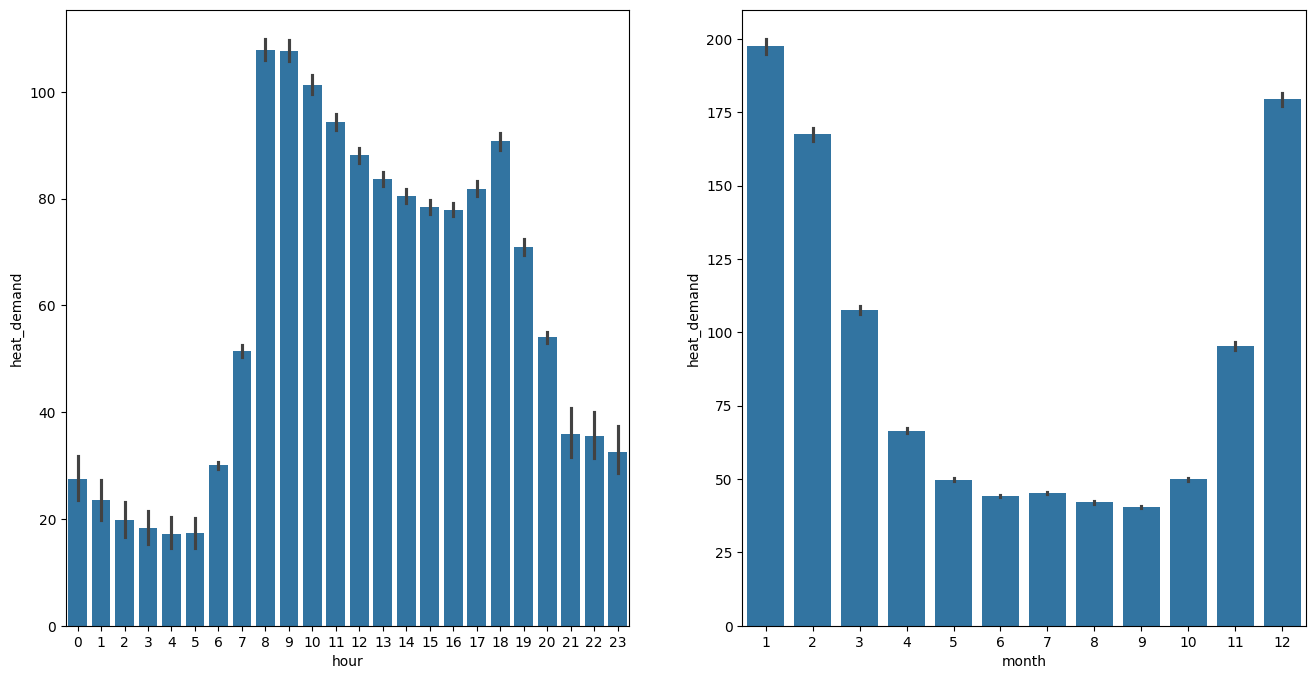

In [133]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.barplot(x='hour',y='heat_demand',data=df)
plt.subplot(1,2,2)
sns.barplot(x='month',y='heat_demand',data=df)
plt.show()

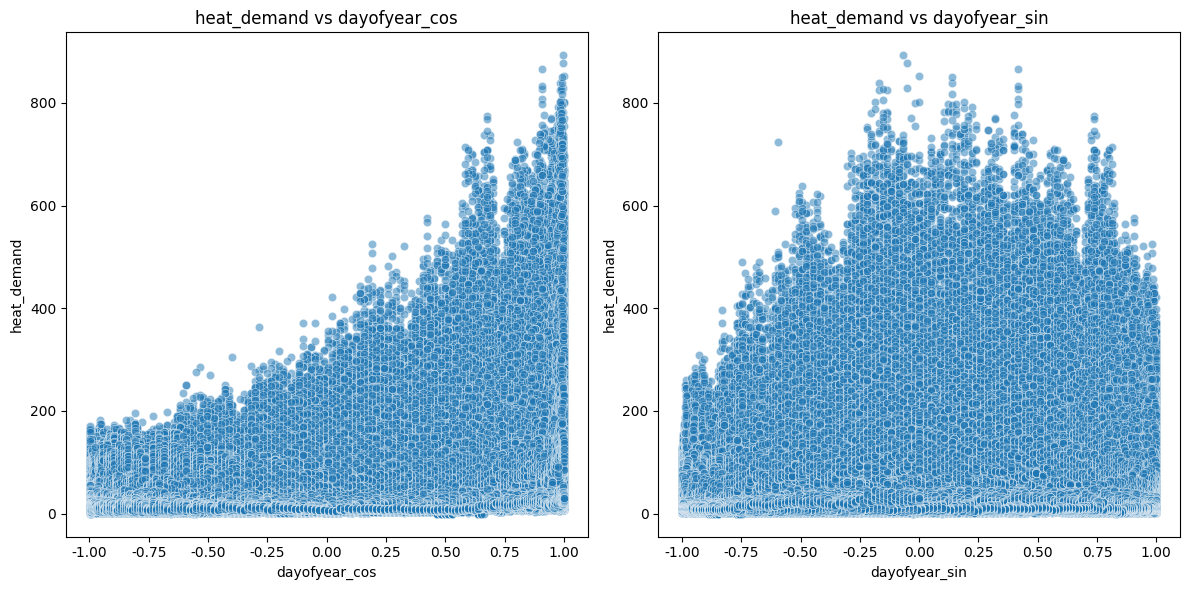

In [134]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='dayofyear_cos', y='heat_demand', data=df, alpha=0.5)
plt.title('heat_demand vs dayofyear_cos')

plt.subplot(1, 2, 2)
sns.scatterplot(x='dayofyear_sin', y='heat_demand', data=df, alpha=0.5)
plt.title('heat_demand vs dayofyear_sin')

plt.tight_layout()
plt.show()

In [135]:
# df['quadrant'] = np.select(
#         [
#             (df['wd'] >= 337.5) | (df['wd'] < 22.5),   # 북 (N)
#             (df['wd'] >= 22.5) & (df['wd'] < 67.5),    # 북동 (NE)
#             (df['wd'] >= 67.5) & (df['wd'] < 112.5),   # 동 (E)
#             (df['wd'] >= 112.5) & (df['wd'] < 157.5),  # 남동 (SE)
#             (df['wd'] >= 157.5) & (df['wd'] < 202.5),  # 남 (S)
#             (df['wd'] >= 202.5) & (df['wd'] < 247.5),  # 남서 (SW)
#             (df['wd'] >= 247.5) & (df['wd'] < 292.5),  # 서 (W)
#             (df['wd'] >= 292.5) & (df['wd'] < 337.5),  # 북서 (NW)
#         ],
#         ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
#         default='기타'  # 예외적처리
#     )

df['quadrant'] = np.select(
        [
            (df['wd'] >= 337.5) | (df['wd'] < 22.5),   # 북 (N)
            (df['wd'] >= 22.5) & (df['wd'] < 67.5),    # 북동 (NE)
            (df['wd'] >= 67.5) & (df['wd'] < 112.5),   # 동 (E)
            (df['wd'] >= 112.5) & (df['wd'] < 157.5),  # 남동 (SE)
            (df['wd'] >= 157.5) & (df['wd'] < 202.5),  # 남 (S)
            (df['wd'] >= 202.5) & (df['wd'] < 247.5),  # 남서 (SW)
            (df['wd'] >= 247.5) & (df['wd'] < 292.5),  # 서 (W)
            (df['wd'] >= 292.5) & (df['wd'] < 337.5),  # 북서 (NW)
        ],
        [1,2,3,4,5,6,7,8],
        default=-99  # 예외적처리
    )

In [136]:
# plt.figure(figsize=(16, 8))
# order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']  # 시계방향 순서
# sns.barplot(x='quadrant', y='heat_demand', data=df, order=order)
# plt.title("풍향 기준 정렬")
# plt.xlabel("풍향 (8방위)")
# plt.ylabel("평균 열수요량")
# plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

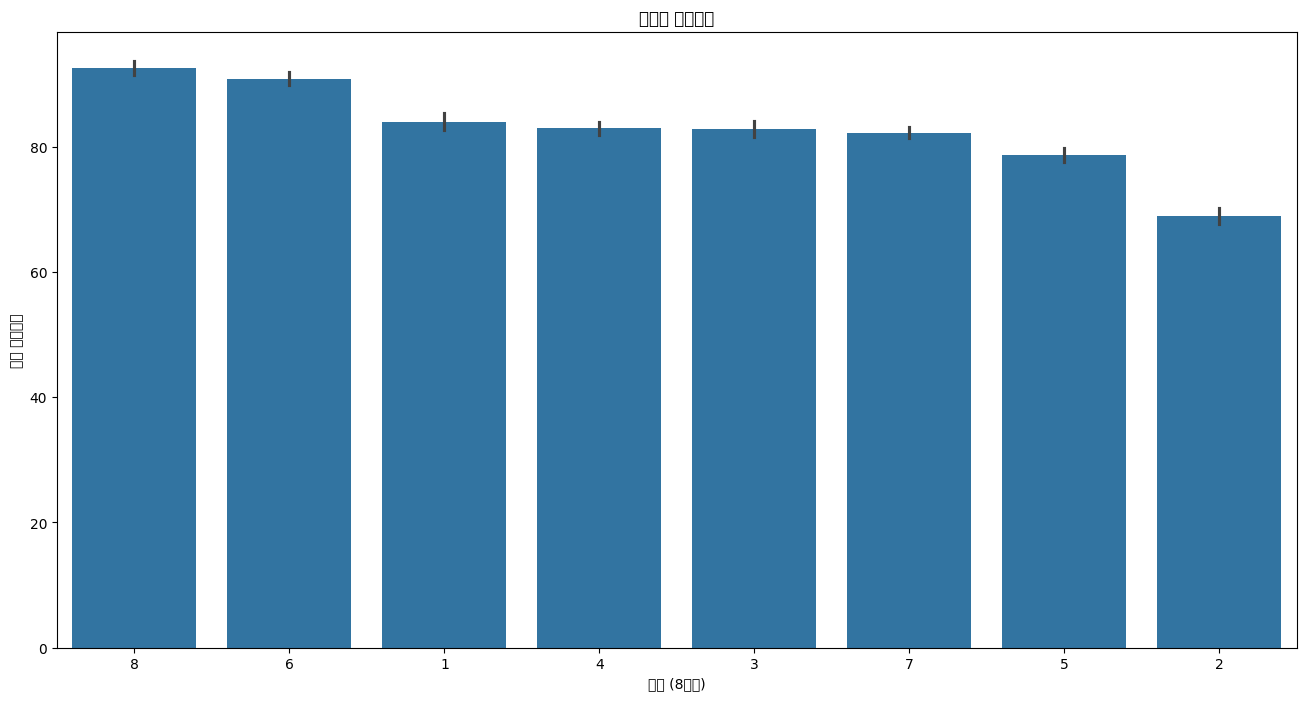

In [137]:
order_by_mean = (
    df.groupby('quadrant')['heat_demand']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

plt.figure(figsize=(16, 8))
sns.barplot(x='quadrant', y='heat_demand', data=df, order=order_by_mean)
plt.title("풍향별 열수요량")
plt.xlabel("풍향 (8방위)")
plt.ylabel("평균 열수요량")
plt.show()

In [138]:
df['rain_day'] = np.where(df['rn_day']>0,1,0)
df.drop('rn_day', axis=1, inplace=True)

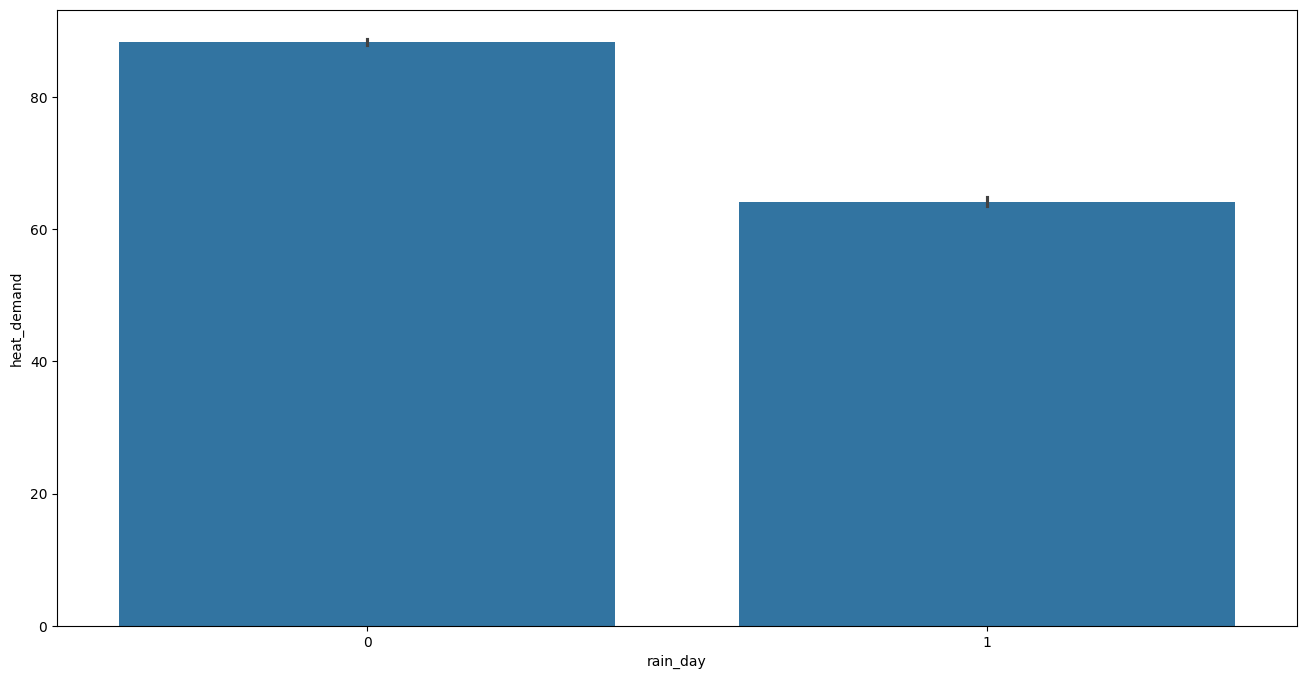

In [139]:
plt.figure(figsize=(16,8))
sns.barplot(x='rain_day',y='heat_demand',data=df)
plt.show()

In [140]:
df.columns

Index(['branch_id', 'ta', 'wd', 'ws', 'rn_hr1', 'hm', 'si', 'ta_chi',
       'heat_demand', 'month', 'hour', 'is_weekend', 'dayofyear_sin',
       'dayofyear_cos', 'quadrant', 'rain_day'],
      dtype='object')

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as spst
import warnings

array=['ta', 'ta_chi', 'ws','rn_hr1','si','month','hour','is_weekend','dayofyear_sin','dayofyear_cos','quadrant']


for i in array:
  result = spst.pearsonr(df[i], df['heat_demand'])
  print('--'*20)
  print(i+' 상관 분석결과')
  print('* 상관계수:', result[0])
  print('* p-value:', result[1])

----------------------------------------
ta 상관 분석결과
* 상관계수: -0.5455980611963774
* p-value: 0.0
----------------------------------------
ta_chi 상관 분석결과
* 상관계수: -0.5480718484660491
* p-value: 0.0
----------------------------------------
ws 상관 분석결과
* 상관계수: -0.07275795600101433
* p-value: 3.9016640625926833e-274
----------------------------------------
rn_hr1 상관 분석결과
* 상관계수: -0.038881381217345946
* p-value: 1.4550534700812578e-79
----------------------------------------
si 상관 분석결과
* 상관계수: -0.0944878019183536
* p-value: 0.0
----------------------------------------
month 상관 분석결과
* 상관계수: -0.14351094655181845
* p-value: 0.0
----------------------------------------
hour 상관 분석결과
* 상관계수: -0.026971401184990335
* p-value: 3.329935811194209e-39
----------------------------------------
is_weekend 상관 분석결과
* 상관계수: -0.018560871045181757
* p-value: 1.9948136571031656e-19
----------------------------------------
dayofyear_sin 상관 분석결과
* 상관계수: 0.1529534006760246
* p-value: 0.0
------------------------------

In [142]:
import scipy.stats as spst

temp = df.loc[df['heat_demand'].notnull()]
parray = []

for branch in ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S']:
    parray.append(temp.loc[df['branch_id'] == branch, 'heat_demand'])

# 리스트를 *로 unpack해서 인자로 넘김
anova = spst.f_oneway(*parray)

print('* f-statistic:', anova.statistic)
print('* p-value:', anova.pvalue)


* f-statistic: 7506.795674251176
* p-value: 0.0


In [143]:
df['quadrant']

,quadrant
7,3
8,3
9,5
10,5
11,6
...,...
499291,7
499292,7
499293,8
499294,7


In [144]:
import scipy.stats as spst

temp = df.loc[df['heat_demand'].notnull()]
parray = []

for branch in [1,2,3,4,5,6,7,8]:
    parray.append(temp.loc[df['wd'] == branch, 'heat_demand'])

# 리스트를 *로 unpack해서 인자로 넘김
anova = spst.f_oneway(*parray)

print('* f-statistic:', anova.statistic)
print('* p-value:', anova.pvalue)


* f-statistic: 1.5627301464379986
* p-value: 0.14631622529581498


In [145]:
from scipy.stats import ttest_ind

# 두 그룹
group0 = temp.loc[df['rain_day'] == 0, 'heat_demand']
group1 = temp.loc[df['rain_day'] == 1, 'heat_demand']

# t-test 수행
t_stat, p_val = ttest_ind(group0, group1, equal_var=False)  # Welch's t-test

print('* t-statistic:', t_stat)
print('* p-value:', p_val)


* t-statistic: 57.67738309495122
* p-value: 0.0


In [146]:
df

,branch_id,ta,wd,ws,rn_hr1,hm,si,ta_chi,heat_demand,month,hour,is_weekend,dayofyear_sin,dayofyear_cos,quadrant,rain_day
7,A,-8.6,88.9,1.2,0.0,63.8,0.00,-8.4,284.0,1,8,0,1.721336e-02,0.999852,3,0
8,A,-7.4,71.6,1.3,0.0,61.2,0.27,-7.5,290.0,1,9,0,1.721336e-02,0.999852,3,0
9,A,-4.7,157.5,0.5,0.0,50.4,0.76,-5.3,285.0,1,10,0,1.721336e-02,0.999852,5,0
10,A,-2.6,184.2,0.9,0.0,41.5,1.40,-3.1,277.0,1,11,0,1.721336e-02,0.999852,5,0
11,A,-2.2,232.4,1.2,0.0,46.1,1.74,-1.6,269.0,1,12,0,1.721336e-02,0.999852,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499291,S,4.4,288.7,2.6,0.0,86.6,0.57,2.0,25.0,12,14,1,6.432491e-16,1.000000,7,1
499292,S,4.4,287.0,2.4,0.0,86.7,0.50,2.6,26.0,12,15,1,6.432491e-16,1.000000,7,1
499293,S,4.9,302.5,2.2,0.0,84.8,0.31,3.0,29.0,12,16,1,6.432491e-16,1.000000,8,1
499294,S,4.4,284.1,1.2,0.0,87.3,0.16,4.4,30.0,12,17,1,6.432491e-16,1.000000,7,1


In [147]:
df.drop(columns=['ta_chi','si','rn_hr1'], axis=1, inplace=True)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1443
[LightGBM] [Info] Number of data points in the train set: 188632, number of used features: 29
[LightGBM] [Info] Start training from score 84.213898
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 13.2289	valid_0's l2: 175.004
LightGBM 결과
RMSE : 13.228898402703914
MAE  : 8.415211006027068


R2   : 0.9821725844528111


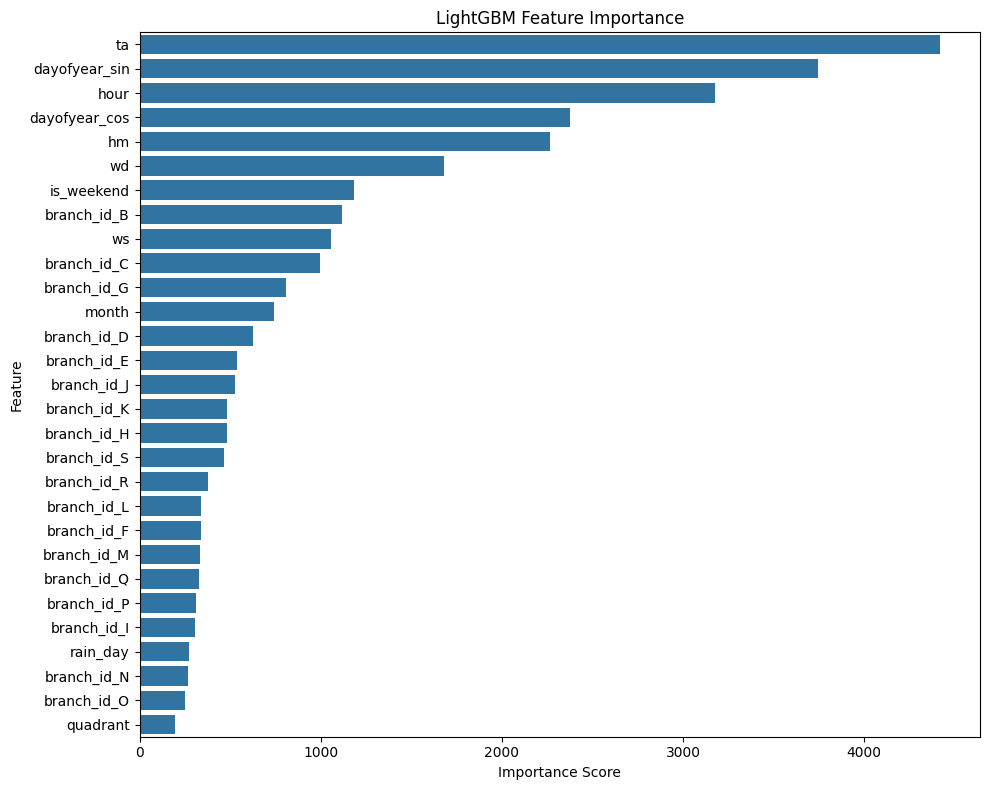

In [148]:
# 원-핫 인코딩
df = pd.get_dummies(df, columns=['branch_id'], drop_first=True)

# x, y 분리
x = df.drop('heat_demand', axis=1)
y = df['heat_demand']

# 분할
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)


# LightGBM 모델 정의
LEARNING_RATE=0.05
model = lightgbm.LGBMRegressor(
    n_estimators=1000,
    learning_rate=LEARNING_RATE,
    objective='regression',
)

# 학습
model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    eval_metric='rmse',
    callbacks=[lightgbm.early_stopping(stopping_rounds=10)]
)
rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, model.predict(x_test)))
# 평가 출력
print("LightGBM 결과")
print("RMSE :", rmse)
print("MAE  :", sk.metrics.mean_absolute_error(y_test, model.predict(x_test)))
print("R2   :", sk.metrics.r2_score(y_test, model.predict(x_test)))

# 중요도 추출 (split은 등장 횟수 기준, gain은 손실 감소량 기준)
importances = model.feature_importances_  # 기본은 split 기준
feature_names = x.columns

# 정리해서 시각화
importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=importance_df, y=importance_df.index)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

<ipython-input-149-2094ee8a2dd5>:11: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-149-2094ee8a2dd5>:11: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-149-2094ee8a2dd5>:11: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-149-2094ee8a2dd5>:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-149-2094ee8a2dd5>:11: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-149-2094ee8a2dd5>:11: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-149-2094ee8a2dd5>:11: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<

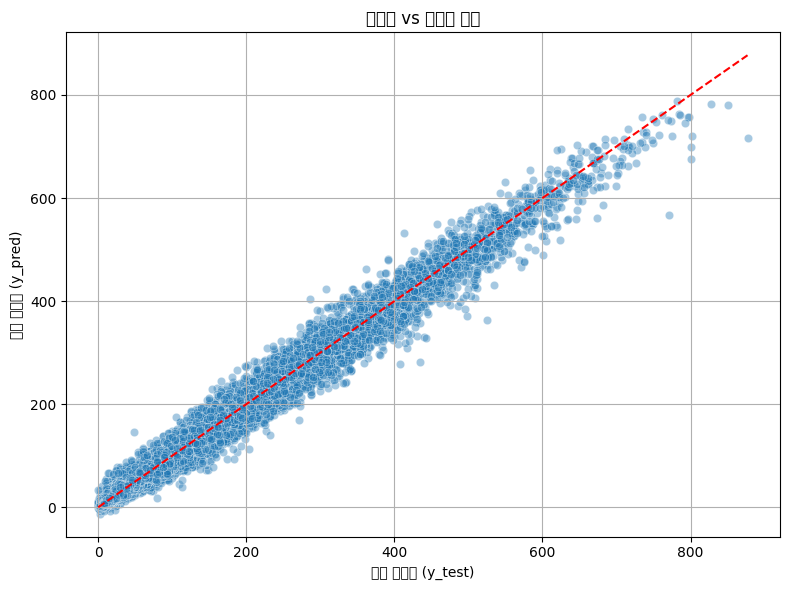

In [149]:
y_pred = model.predict(x_test)

# 산점도 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 대각선
plt.xlabel("실제 열수요 (y_test)")
plt.ylabel("예측 열수요 (y_pred)")
plt.title("예측값 vs 실제값 비교")
plt.grid(True)
plt.tight_layout()
plt.show()